This notebook includes runs related to unmixing by using:

1. A very simple CNN, of various different channel sizes. These sizes are:
    - [4, 8]
    - [8, 16]
    - [8, 16, 32]
    - [16, 32, 64]
    - [16, 32, 64, 128]
    - [32, 64, 128, 256]
    - [32, 64, 128, 256, 512]
2. Of varying learning rates fine tuned for the given model.
3. With dropout, optimized using AdamW.
4. A loss of simple MSE, with a small additional terms for sum of residuals.
5. With a training loop that loops over the entire training dataset at each epoch, with a max epochs of 80.
6. Data separated into 1500 training samples, 100 static validation samples, and 123 static test samples.
7. Trained using a GPU.
8. Standard Normed Variate datasets.
9. Activations of LeakyReLU throughout the model, following BatchNorm, with the final activation layer of ReLU+L1norm.
10. Models initialized using Kaiming (He), tuned for LeakyReLUl leak constant of 0.2.


### Imports, data, model initialization, and various other setups

In [1]:
# Set up autoreload
%load_ext autoreload
%autoreload 2

In [2]:
# Sys Imports
import sys
from pathlib import Path

github_root = Path.cwd().resolve().parents[3]
sys.path.append(str(github_root))

In [3]:
# Self-def imports

from src.dl.data import get_data
from src.dl.models.cnn import CNN
from src.dl.train import train_model

In [4]:
# Package imports
import torch
import torch.nn as nn

In [5]:
# Get device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [6]:
# Data hyperparams
save_path = rf"{github_root}\data\simpler_data_rwc.csv"

batch_size = 32
epoch = 100
n_tb_epoch = 47

In [7]:
# Define model configs

models_list = [
    {'hidden_ch': [4, 8]},
    {'hidden_ch': [8, 16]},
    {'hidden_ch': [8, 16, 32]},
    {'hidden_ch': [16, 32, 64]},
    {'hidden_ch': [16, 32, 64, 128]},
    {'hidden_ch': [32, 64, 128, 256]},
    {'hidden_ch': [32, 64, 128, 256, 512]}
]

lr_list = [1e-3, 1.25e-3, 2.5e-3, 5e-3, 7.5e-3, 1e-4, 1e-4]

dir_list = [
    'cnn_8',
    'cnn_16',
    'cnn_32',
    'cnn_64',
    'cnn_128',
    'cnn_256',
    'cnn_512'
]

name_list = [
        'CNN_8',
        'CNN_16',
        'CNN_32',
        'CNN_64',
        'CNN_128',
        'CNN_256',
        'CNN_512'
    ]

# Create dirs

for dir_name in dir_list:
    save_dir = github_root / 'runs' / 'dl' / 'simpler_data' / 'cnn' / dir_name
    save_dir.mkdir(parents=True, exist_ok=True)

### Model train loop

Epoch 1/100, Step 1/47, Train Loss: 0.279988
Epoch 1/100, Step 2/47, Train Loss: 0.218785
Epoch 1/100, Step 3/47, Train Loss: 0.211120
Epoch 1/100, Step 4/47, Train Loss: 0.197425
Epoch 1/100, Step 5/47, Train Loss: 0.173251
Epoch 1/100, Step 6/47, Train Loss: 0.117235
Epoch 1/100, Step 7/47, Train Loss: 0.184835
Epoch 1/100, Step 8/47, Train Loss: 0.148703
Epoch 1/100, Step 9/47, Train Loss: 0.147429
Epoch 1/100, Step 10/47, Train Loss: 0.151758
Epoch 1/100, Step 11/47, Train Loss: 0.126050
Epoch 1/100, Step 12/47, Train Loss: 0.139325
Epoch 1/100, Step 13/47, Train Loss: 0.083815
Epoch 1/100, Step 14/47, Train Loss: 0.107753
Epoch 1/100, Step 15/47, Train Loss: 0.118150
Epoch 1/100, Step 16/47, Train Loss: 0.126108
Epoch 1/100, Step 17/47, Train Loss: 0.143958
Epoch 1/100, Step 18/47, Train Loss: 0.124424
Epoch 1/100, Step 19/47, Train Loss: 0.166712
Epoch 1/100, Step 20/47, Train Loss: 0.137107
Epoch 1/100, Step 21/47, Train Loss: 0.085907
Epoch 1/100, Step 22/47, Train Loss: 0.1431

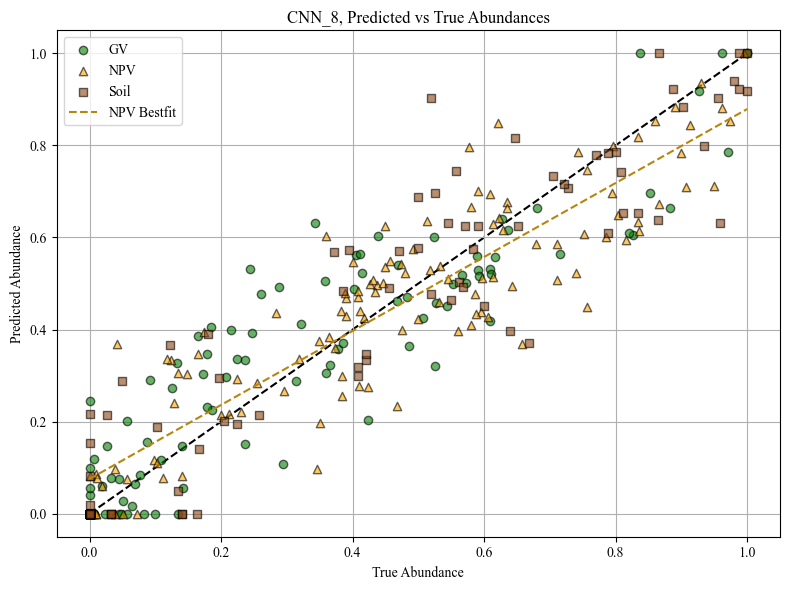

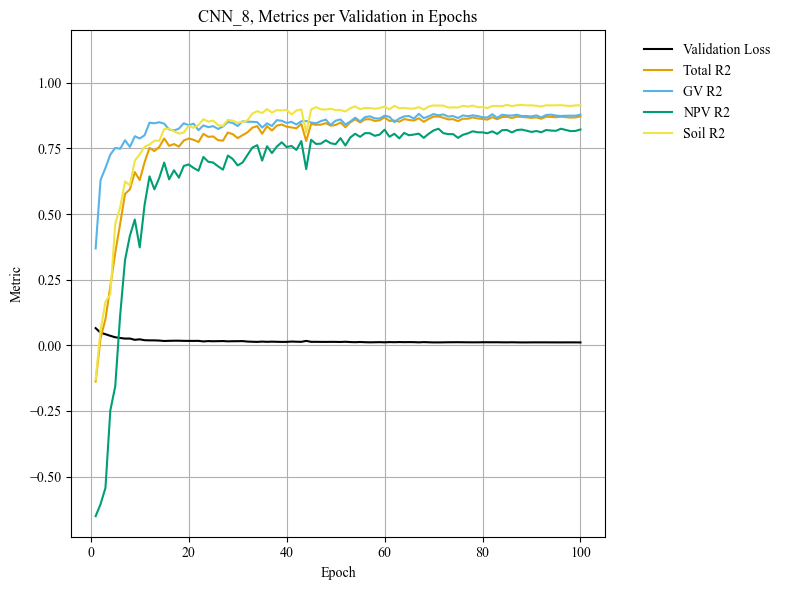

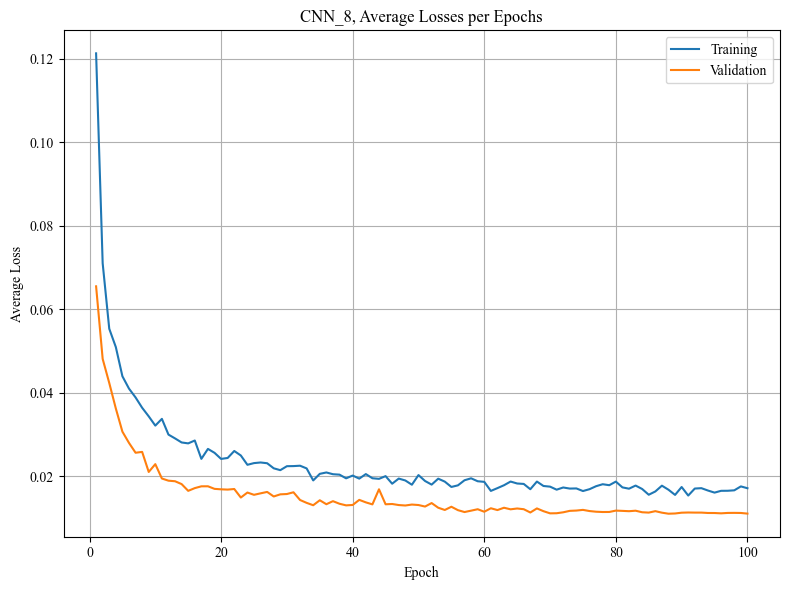

Testing complete
Epoch 1/100, Step 1/47, Train Loss: 0.299469
Epoch 1/100, Step 2/47, Train Loss: 0.351161
Epoch 1/100, Step 3/47, Train Loss: 0.262891
Epoch 1/100, Step 4/47, Train Loss: 0.247190
Epoch 1/100, Step 5/47, Train Loss: 0.329156
Epoch 1/100, Step 6/47, Train Loss: 0.254159
Epoch 1/100, Step 7/47, Train Loss: 0.192573
Epoch 1/100, Step 8/47, Train Loss: 0.233642
Epoch 1/100, Step 9/47, Train Loss: 0.238923
Epoch 1/100, Step 10/47, Train Loss: 0.200922
Epoch 1/100, Step 11/47, Train Loss: 0.208148
Epoch 1/100, Step 12/47, Train Loss: 0.147081
Epoch 1/100, Step 13/47, Train Loss: 0.155717
Epoch 1/100, Step 14/47, Train Loss: 0.171552
Epoch 1/100, Step 15/47, Train Loss: 0.167150
Epoch 1/100, Step 16/47, Train Loss: 0.156762
Epoch 1/100, Step 17/47, Train Loss: 0.163117
Epoch 1/100, Step 18/47, Train Loss: 0.155211
Epoch 1/100, Step 19/47, Train Loss: 0.160191
Epoch 1/100, Step 20/47, Train Loss: 0.130016
Epoch 1/100, Step 21/47, Train Loss: 0.091613
Epoch 1/100, Step 22/47, T

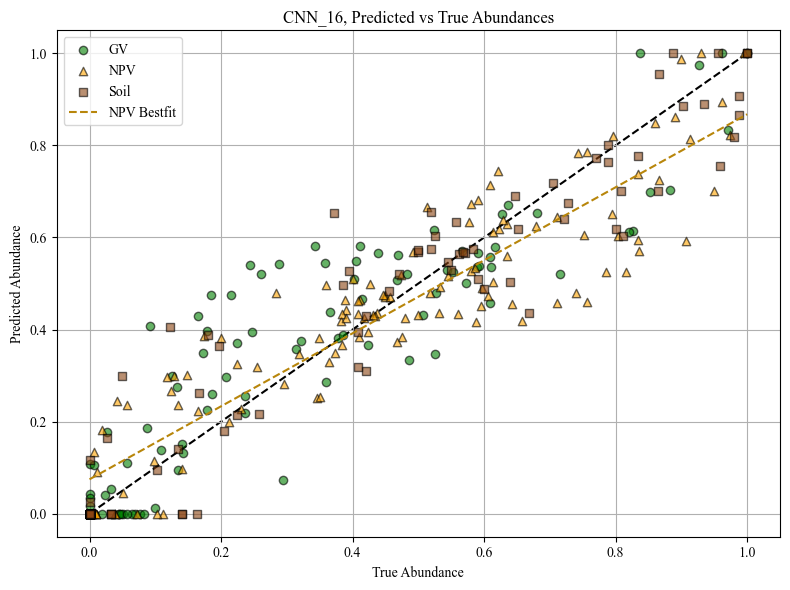

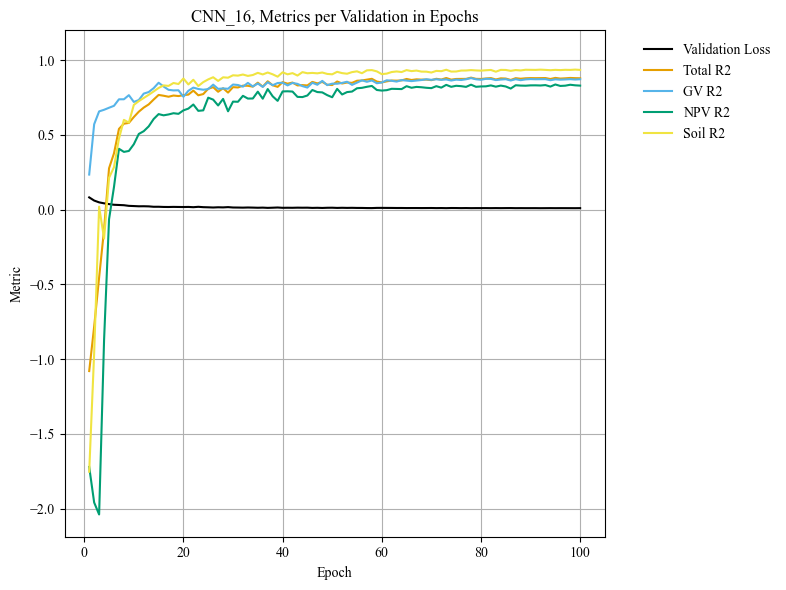

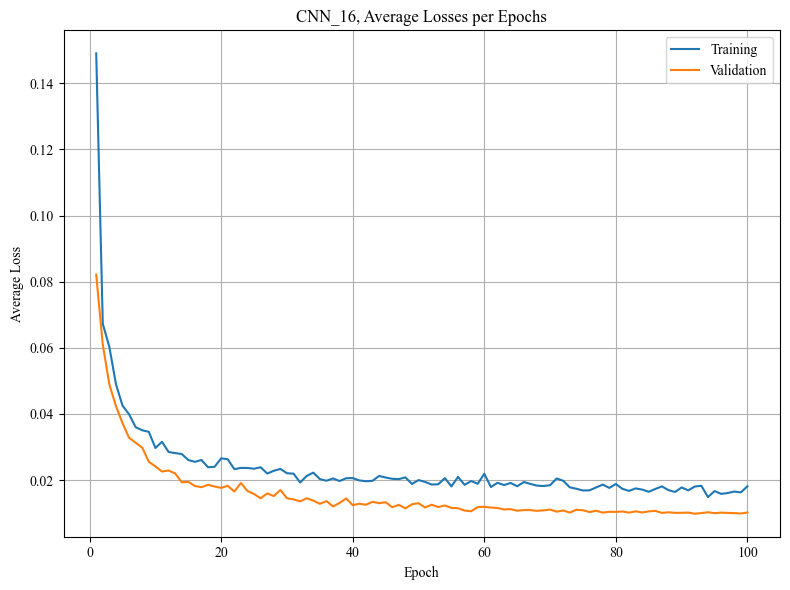

Testing complete
Epoch 1/100, Step 1/47, Train Loss: 0.237443
Epoch 1/100, Step 2/47, Train Loss: 0.208244
Epoch 1/100, Step 3/47, Train Loss: 0.199301
Epoch 1/100, Step 4/47, Train Loss: 0.146471
Epoch 1/100, Step 5/47, Train Loss: 0.101580
Epoch 1/100, Step 6/47, Train Loss: 0.130732
Epoch 1/100, Step 7/47, Train Loss: 0.114135
Epoch 1/100, Step 8/47, Train Loss: 0.123803
Epoch 1/100, Step 9/47, Train Loss: 0.108470
Epoch 1/100, Step 10/47, Train Loss: 0.109427
Epoch 1/100, Step 11/47, Train Loss: 0.110219
Epoch 1/100, Step 12/47, Train Loss: 0.109795
Epoch 1/100, Step 13/47, Train Loss: 0.119876
Epoch 1/100, Step 14/47, Train Loss: 0.121022
Epoch 1/100, Step 15/47, Train Loss: 0.108620
Epoch 1/100, Step 16/47, Train Loss: 0.115931
Epoch 1/100, Step 17/47, Train Loss: 0.104748
Epoch 1/100, Step 18/47, Train Loss: 0.091129
Epoch 1/100, Step 19/47, Train Loss: 0.076259
Epoch 1/100, Step 20/47, Train Loss: 0.087457
Epoch 1/100, Step 21/47, Train Loss: 0.107950
Epoch 1/100, Step 22/47, T

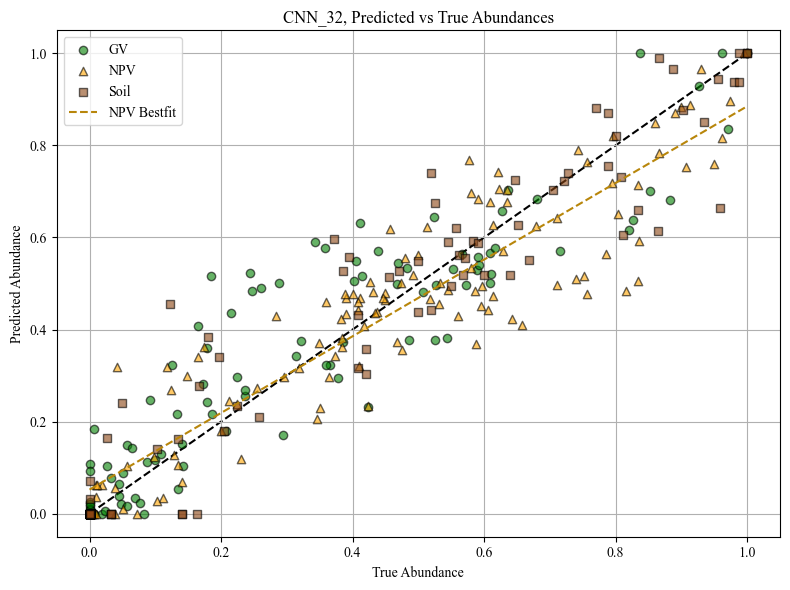

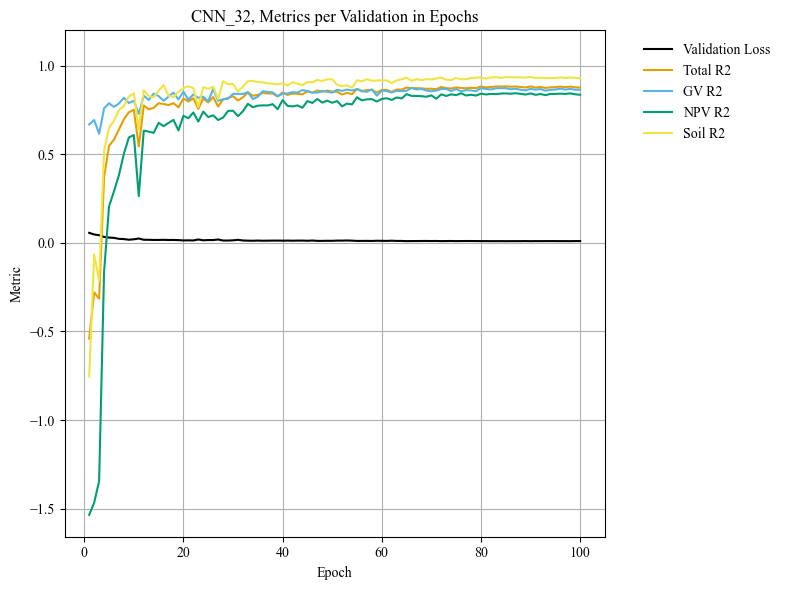

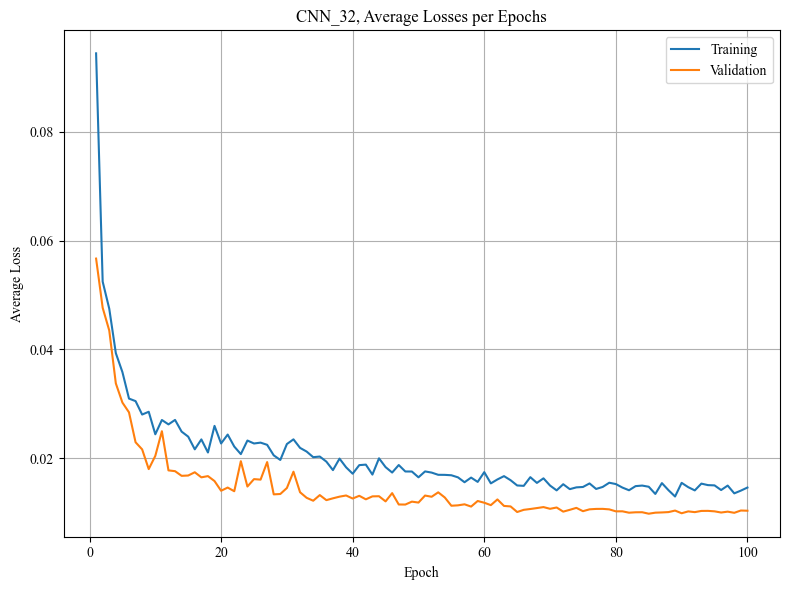

Testing complete
Epoch 1/100, Step 1/47, Train Loss: 0.215229
Epoch 1/100, Step 2/47, Train Loss: 0.292554
Epoch 1/100, Step 3/47, Train Loss: 0.234848
Epoch 1/100, Step 4/47, Train Loss: 0.103830
Epoch 1/100, Step 5/47, Train Loss: 0.084918
Epoch 1/100, Step 6/47, Train Loss: 0.072069
Epoch 1/100, Step 7/47, Train Loss: 0.069547
Epoch 1/100, Step 8/47, Train Loss: 0.050500
Epoch 1/100, Step 9/47, Train Loss: 0.072240
Epoch 1/100, Step 10/47, Train Loss: 0.067296
Epoch 1/100, Step 11/47, Train Loss: 0.087590
Epoch 1/100, Step 12/47, Train Loss: 0.060864
Epoch 1/100, Step 13/47, Train Loss: 0.049612
Epoch 1/100, Step 14/47, Train Loss: 0.070926
Epoch 1/100, Step 15/47, Train Loss: 0.046208
Epoch 1/100, Step 16/47, Train Loss: 0.054842
Epoch 1/100, Step 17/47, Train Loss: 0.051643
Epoch 1/100, Step 18/47, Train Loss: 0.072543
Epoch 1/100, Step 19/47, Train Loss: 0.040926
Epoch 1/100, Step 20/47, Train Loss: 0.048293
Epoch 1/100, Step 21/47, Train Loss: 0.061068
Epoch 1/100, Step 22/47, T

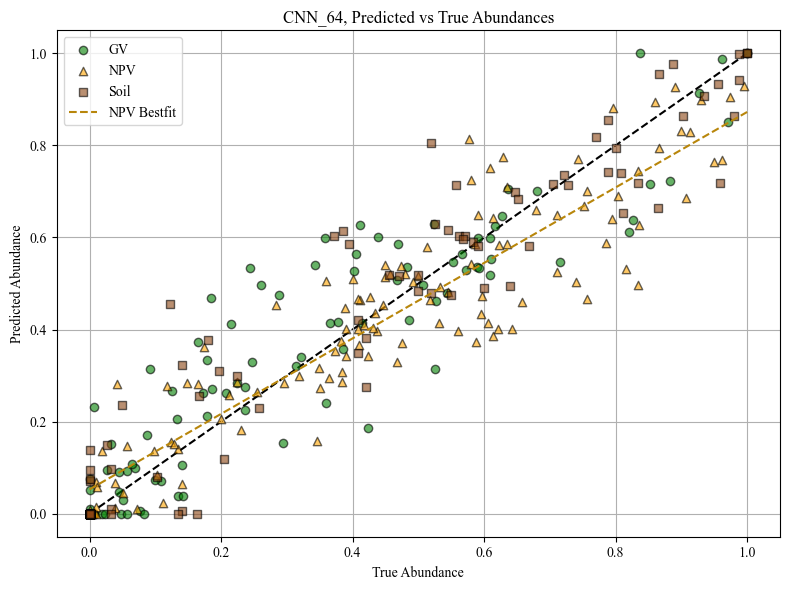

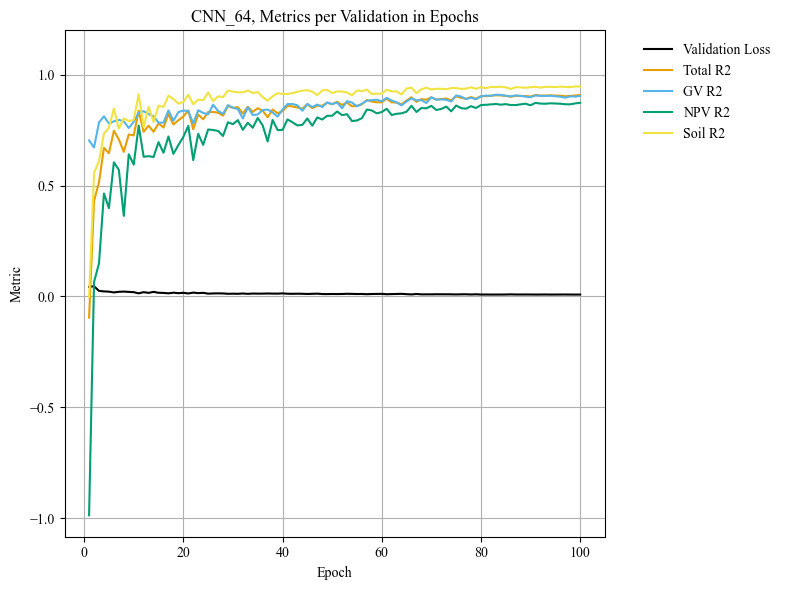

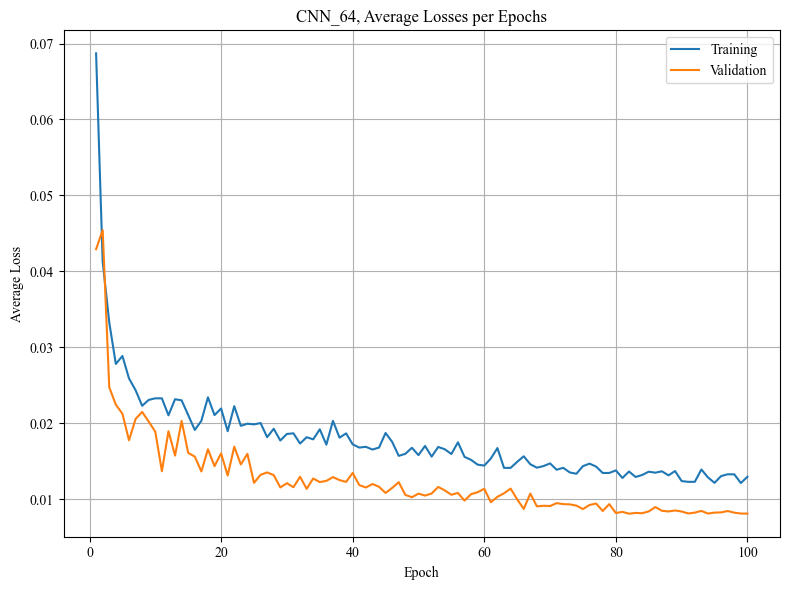

Testing complete
Epoch 1/100, Step 1/47, Train Loss: 0.178235
Epoch 1/100, Step 2/47, Train Loss: 0.234493
Epoch 1/100, Step 3/47, Train Loss: 0.184134
Epoch 1/100, Step 4/47, Train Loss: 0.074690
Epoch 1/100, Step 5/47, Train Loss: 0.090615
Epoch 1/100, Step 6/47, Train Loss: 0.067944
Epoch 1/100, Step 7/47, Train Loss: 0.088376
Epoch 1/100, Step 8/47, Train Loss: 0.061912
Epoch 1/100, Step 9/47, Train Loss: 0.080341
Epoch 1/100, Step 10/47, Train Loss: 0.076455
Epoch 1/100, Step 11/47, Train Loss: 0.044269
Epoch 1/100, Step 12/47, Train Loss: 0.045531
Epoch 1/100, Step 13/47, Train Loss: 0.061908
Epoch 1/100, Step 14/47, Train Loss: 0.054730
Epoch 1/100, Step 15/47, Train Loss: 0.066669
Epoch 1/100, Step 16/47, Train Loss: 0.066574
Epoch 1/100, Step 17/47, Train Loss: 0.062015
Epoch 1/100, Step 18/47, Train Loss: 0.051041
Epoch 1/100, Step 19/47, Train Loss: 0.057102
Epoch 1/100, Step 20/47, Train Loss: 0.067034
Epoch 1/100, Step 21/47, Train Loss: 0.059071
Epoch 1/100, Step 22/47, T

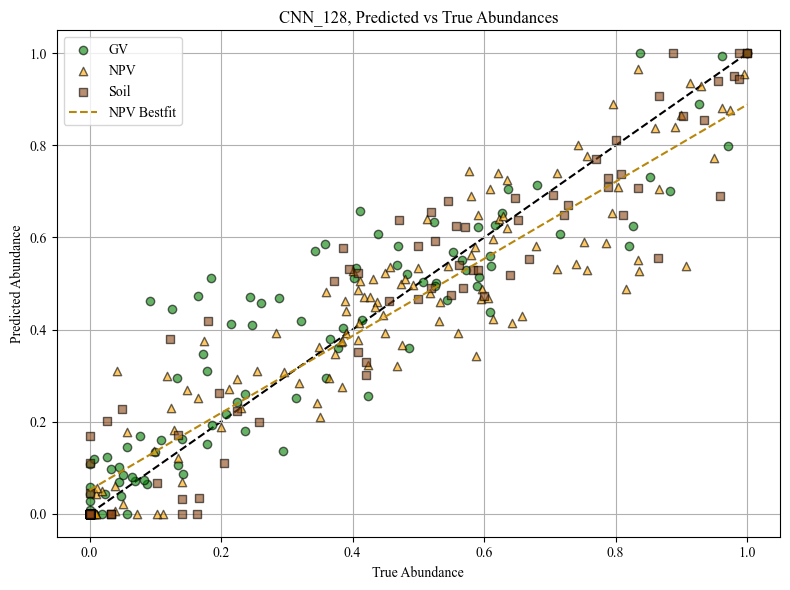

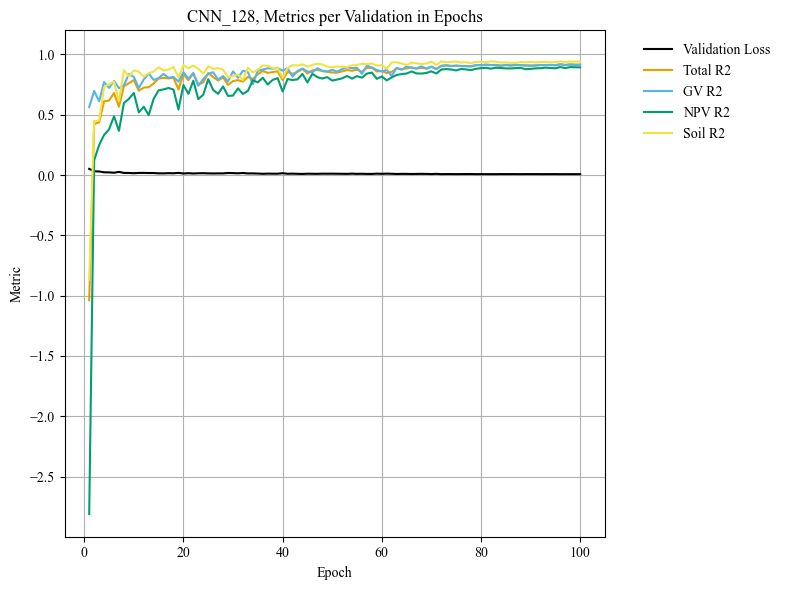

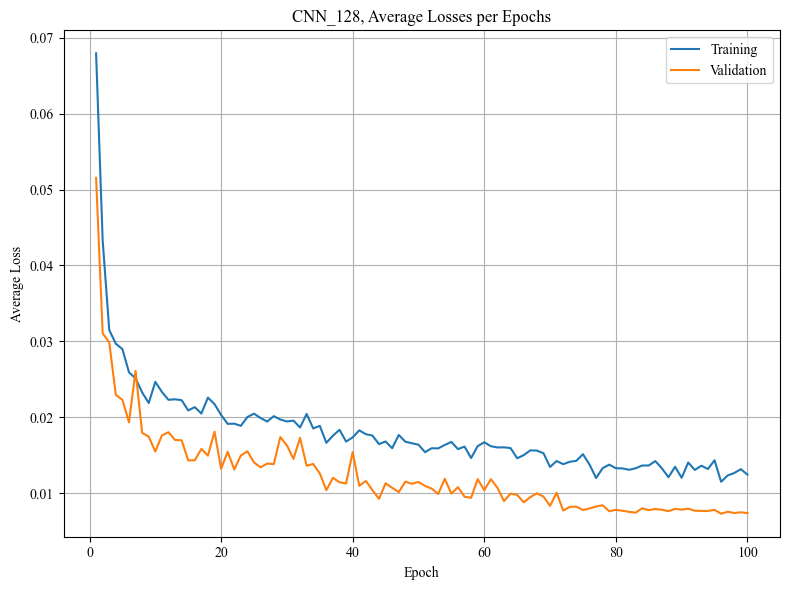

Testing complete
Epoch 1/100, Step 1/47, Train Loss: 0.254161
Epoch 1/100, Step 2/47, Train Loss: 0.205619
Epoch 1/100, Step 3/47, Train Loss: 0.215840
Epoch 1/100, Step 4/47, Train Loss: 0.210417
Epoch 1/100, Step 5/47, Train Loss: 0.242981
Epoch 1/100, Step 6/47, Train Loss: 0.273194
Epoch 1/100, Step 7/47, Train Loss: 0.235778
Epoch 1/100, Step 8/47, Train Loss: 0.097559
Epoch 1/100, Step 9/47, Train Loss: 0.191969
Epoch 1/100, Step 10/47, Train Loss: 0.166230
Epoch 1/100, Step 11/47, Train Loss: 0.142635
Epoch 1/100, Step 12/47, Train Loss: 0.118054
Epoch 1/100, Step 13/47, Train Loss: 0.113480
Epoch 1/100, Step 14/47, Train Loss: 0.149551
Epoch 1/100, Step 15/47, Train Loss: 0.142637
Epoch 1/100, Step 16/47, Train Loss: 0.161259
Epoch 1/100, Step 17/47, Train Loss: 0.109793
Epoch 1/100, Step 18/47, Train Loss: 0.129279
Epoch 1/100, Step 19/47, Train Loss: 0.117090
Epoch 1/100, Step 20/47, Train Loss: 0.116013
Epoch 1/100, Step 21/47, Train Loss: 0.071827
Epoch 1/100, Step 22/47, T

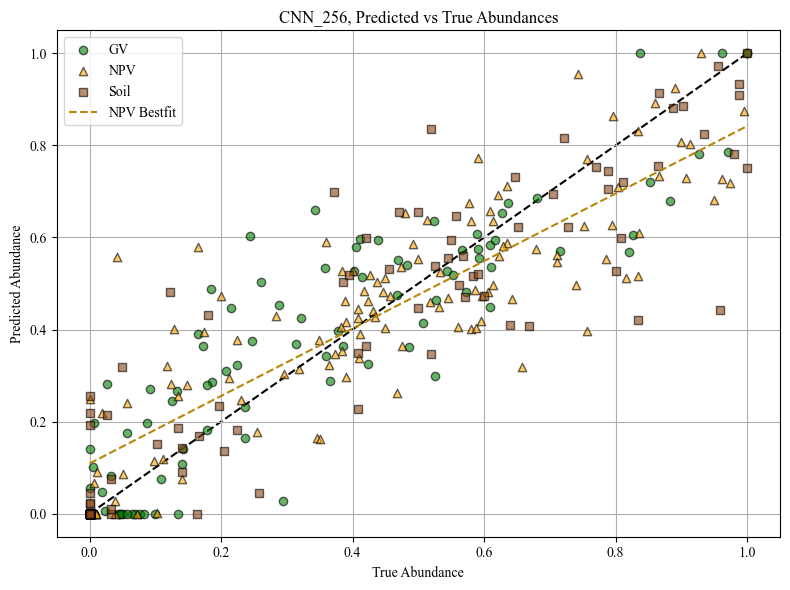

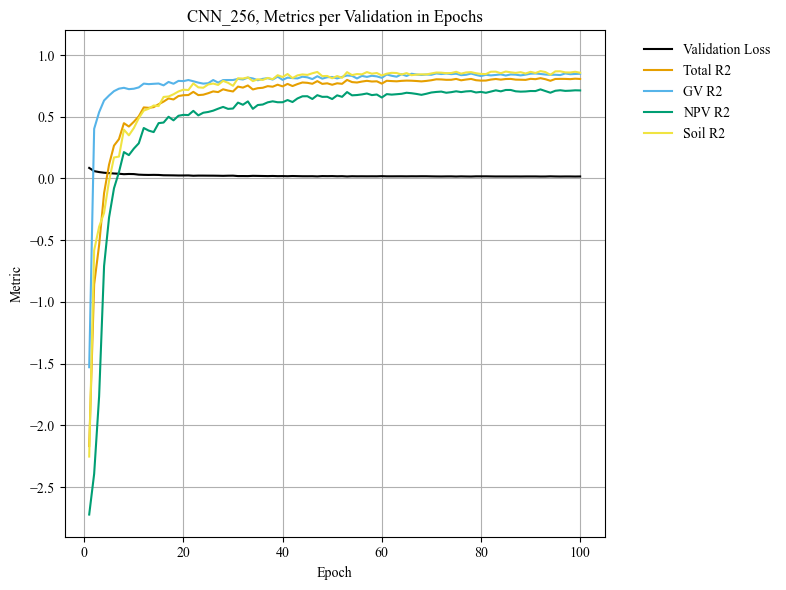

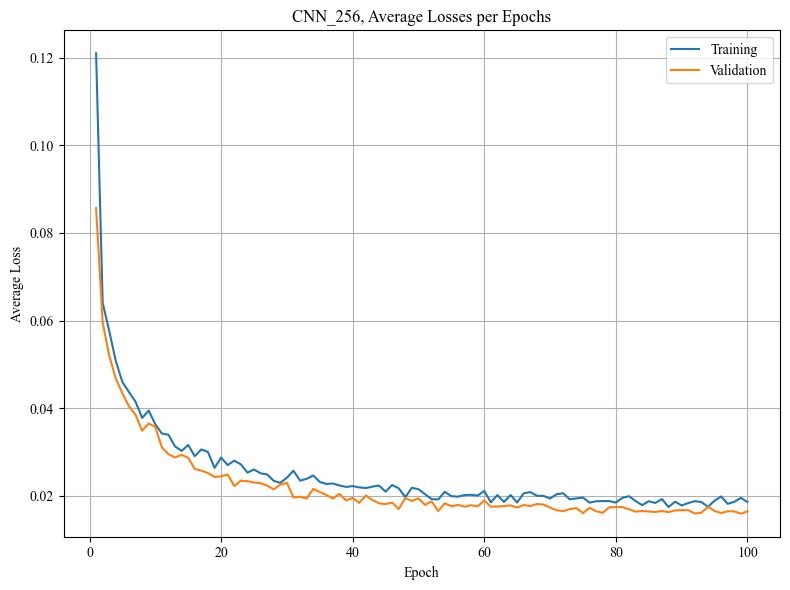

Testing complete
Epoch 1/100, Step 1/47, Train Loss: 0.289158
Epoch 1/100, Step 2/47, Train Loss: 0.264610
Epoch 1/100, Step 3/47, Train Loss: 0.231420
Epoch 1/100, Step 4/47, Train Loss: 0.203260
Epoch 1/100, Step 5/47, Train Loss: 0.226070
Epoch 1/100, Step 6/47, Train Loss: 0.188346
Epoch 1/100, Step 7/47, Train Loss: 0.167857
Epoch 1/100, Step 8/47, Train Loss: 0.153497
Epoch 1/100, Step 9/47, Train Loss: 0.105338
Epoch 1/100, Step 10/47, Train Loss: 0.137453
Epoch 1/100, Step 11/47, Train Loss: 0.087627
Epoch 1/100, Step 12/47, Train Loss: 0.133096
Epoch 1/100, Step 13/47, Train Loss: 0.064717
Epoch 1/100, Step 14/47, Train Loss: 0.086034
Epoch 1/100, Step 15/47, Train Loss: 0.116284
Epoch 1/100, Step 16/47, Train Loss: 0.122037
Epoch 1/100, Step 17/47, Train Loss: 0.116940
Epoch 1/100, Step 18/47, Train Loss: 0.125633
Epoch 1/100, Step 19/47, Train Loss: 0.109997
Epoch 1/100, Step 20/47, Train Loss: 0.113046
Epoch 1/100, Step 21/47, Train Loss: 0.104292
Epoch 1/100, Step 22/47, T

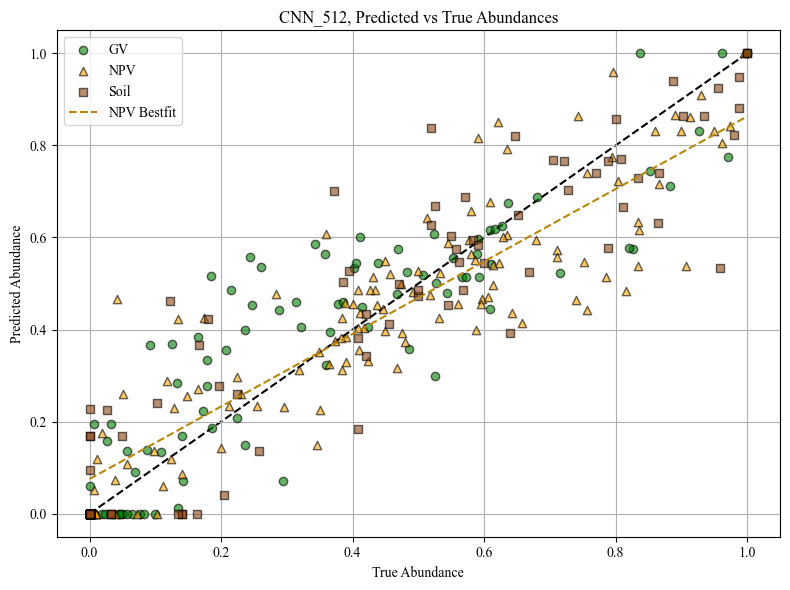

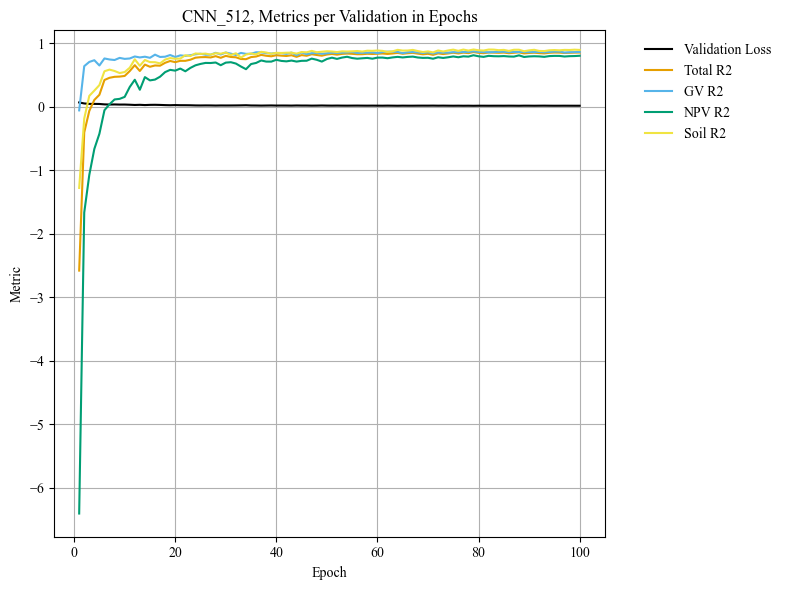

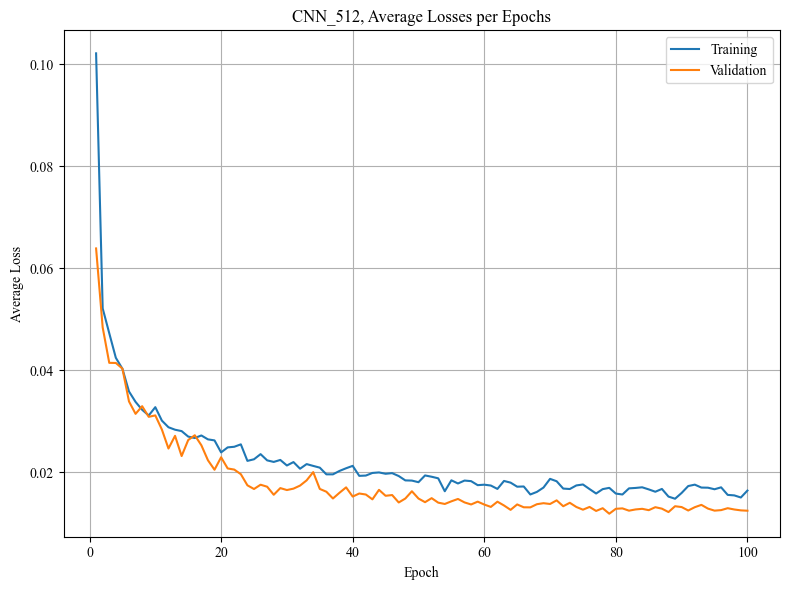

Testing complete


In [8]:
cnn_dict = {}

for i in range(len(models_list)):
    
    cfg_dict = models_list[i]
    lr = lr_list[i]
    save_dir = github_root / 'runs' / 'dl' / 'simpler_data' / 'cnn' / dir_list[i]
    model_name = name_list[i]

    dataloaders = get_data(save_path=save_path, spec_range=[900, 1690], batch_size=32, SNV=True)
    model = CNN(**cfg_dict).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-2)
    lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epoch*n_tb_epoch, eta_min=1e-6)
    loss = nn.MSELoss()

    model_dict = train_model(
        model=model,
        loss_fn=loss,
        optimizer=optimizer,
        lr_scheduler=lr_scheduler,
        configured_data=dataloaders,
        n_epoch=epoch,
        n_tb_epoch=n_tb_epoch,
        device=device,
        dtype=torch.float32,
        save_dir=save_dir,
        model_name=model_name,
        fine_tuning=False
    )

    cnn_dict[model_name] = model_dict

In [12]:
import pickle
with open('cnn_dict.pkl', 'wb') as fp:
    pickle.dump(cnn_dict, fp)

In [13]:
# Best model
print(cnn_dict['CNN_64']['metrics_total'])

[[3.33210000e+04 1.31930200e+06 1.00738443e-02 8.69104445e-01
  8.77276897e-01 7.94651449e-01 9.35384929e-01 6.64377883e-02
  6.49055764e-02 8.46040621e-02 4.98037189e-02]]


In [14]:
for i in cnn_dict.keys():
    print(f"For {i}, NPV R2: {cnn_dict[i]['metrics_total'][0][5]}, param#: {cnn_dict[i]['metrics_total'][0][0]}")

For CNN_8, NPV R2: 0.7617353200912476, param#: 11185.0
For CNN_16, NPV R2: 0.775685727596283, param#: 12089.0
For CNN_32, NPV R2: 0.8020049333572388, param#: 16633.0
For CNN_64, NPV R2: 0.794651448726654, param#: 33321.0
For CNN_128, NPV R2: 0.805095374584198, param#: 103721.0
For CNN_256, NPV R2: 0.6337568759918213, param#: 379401.0
For CNN_512, NPV R2: 0.7285876274108887, param#: 1496585.0
